In [1]:
import numpy as np
import torch 
import gymnasium as gym
import matplotlib.pyplot as plt
import dill

from copy import deepcopy
from tqdm import tqdm
from four_room.env import FourRoomsEnv
from four_room.wrappers import gym_wrapper, gym_wrapper_state
from four_room.constants import state_to_q, state_to_q_np
from rnd_exploration.dataset import State
from four_room.constants import train_config, val_config, test_config, size
from uvu.uvu import UVU
from dqn.model import DQN
from utils.episode import LastEpisode
from dqn.counter import MovingCountBasedUncertainty
from utils.record_scores import record_uvu_scores, record_dqn_scores
from four_room.utils import obs_to_state, obs_to_img, reverse_doors
from four_room.shortest_path import find_all_action_values
from plot_interactive import find_states, plot_env_heatmap

gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)


%load_ext autoreload
%autoreload 2

c:\Users\garga\Documents\Uni\RND DQN\four_room\venv\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment MiniGrid-FourRooms-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\garga\Documents\Uni\RND DQN\four_room\venv\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment MiniGrid-FourRooms-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [2]:
def get_state(obs, use_cnn):
    if use_cnn:
        return obs_to_state(obs)
    else:
        first = [int(item) for item in obs[:5]]
        return tuple(first + list(reverse_doors(obs)))

In [18]:
use_cnn = True

env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )
    
val_env = gym_wrapper_state(gym.make(
        'MiniGrid-FourRooms-v1', 
        agent_pos= train_config['agent positions'],
        goal_pos = train_config['goal positions'],
        doors_pos = train_config['topologies'],
        agent_dir = train_config['agent directions'],
        size=size
    ),
)

obs, _ = env.reset()
obs2, _ = env.reset()

using DQNBaseAction
using DQNBaseAction


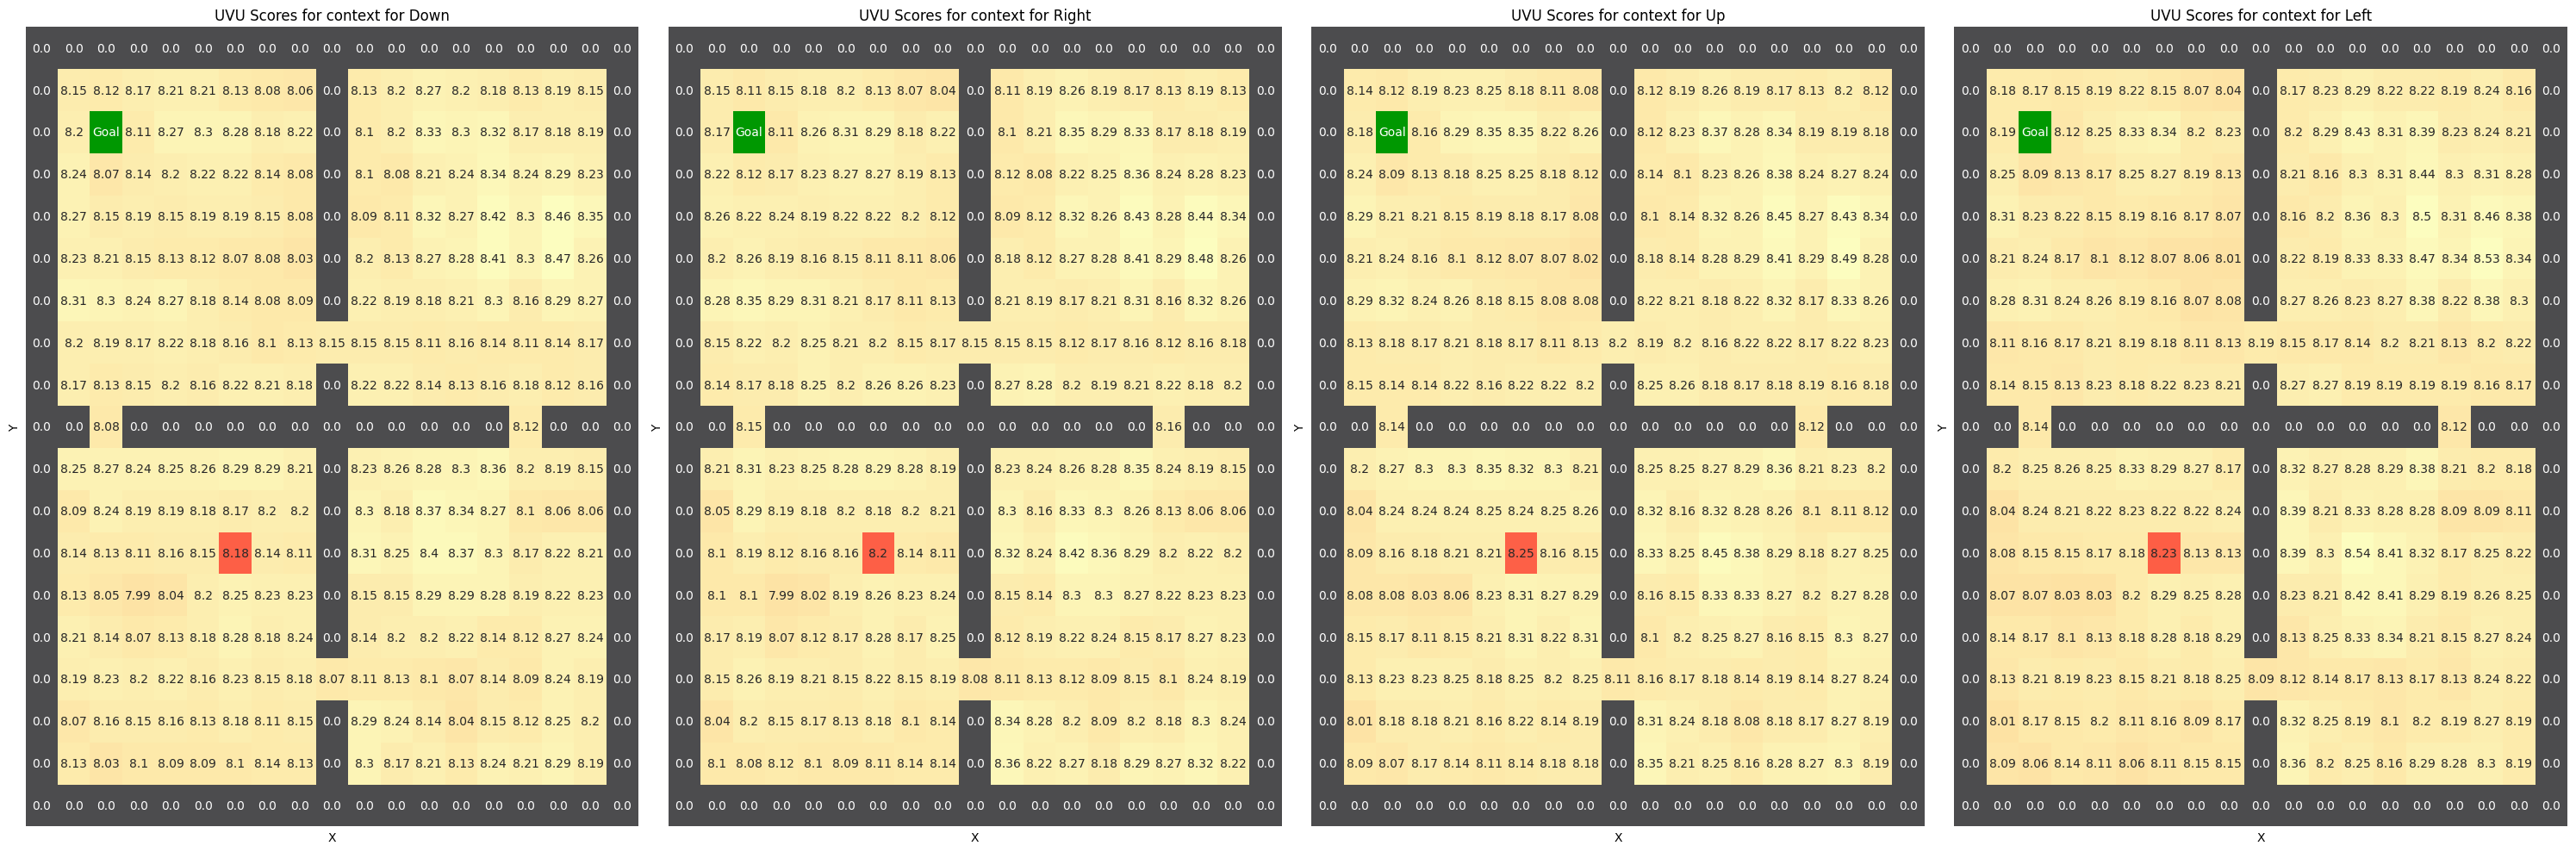

In [ ]:
agent = UVU(
    env=env,
    val_env=val_env,
    tau=0.1,
    lr=1e-4,
    gamma=0.99,
    boostrap_prob=0.8,
    device='cuda',
    modulation='one_hot', 
    use_cnn=use_cnn,
    use_action=True, 
    use_dual=False, 
    use_norm=True, 
    hidden_layers=[512, 512, 512],
    hidden_layers_g=[512, 512],
    init_func='kaiming',
    scale=1, 
    residual=False,
    zero_params=False, 
    num_heads=512,
)

# agent = DQN(
#     env=env,
#     val_env=val_env,
#     capacity=1000,
#     tau=0.001,
#     lr=3e-4,
#     device='cuda',
#     use_cnn=True,
#     cnn_features=1024,
#     hidden_layers=[1024, 2048, 1024],
#     residual=True
# )

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0, use_cnn=use_cnn)
uvu_scores = uvu_scores 
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False,
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout() 


In [33]:
env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )

done = False
context = 0
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
loss = 0
postfix = {}
for step in (pbar := tqdm(range(1, 5001))):
    state = get_state(obs, use_cnn=use_cnn)
    q = state_to_q_np[context, state[0], state[1], state[2]]
    if np.random.random() < 0.0:
        action = env.action_space.sample()
    else:
        action = q.argmax() if isinstance(q, np.ndarray) else np.array(q).argmax()
    
    obs_prime, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state_next = get_state(obs_prime, use_cnn=use_cnn)
    q_next = state_to_q_np[context, state_next[0], state_next[1], state_next[2]]
    next_action = q_next.argmax()
        
    agent.buffer.update(obs, action, reward, obs_prime, next_action, int(done), q_value=q)
    obs = obs_prime

    if done:
        env.get_wrapper_attr('set_context')(context)
        obs, _ = env.reset()
    
    if agent.buffer.size > 128:
        loss = agent.update_step(128)
        postfix["loss"] = loss.item()
        pbar.set_postfix(postfix)
        agent.soft_update()
    

  1%|          | 58/5000 [00:00<00:08, 567.66it/s]

100%|██████████| 5000/5000 [02:23<00:00, 34.91it/s, loss=1.22] 


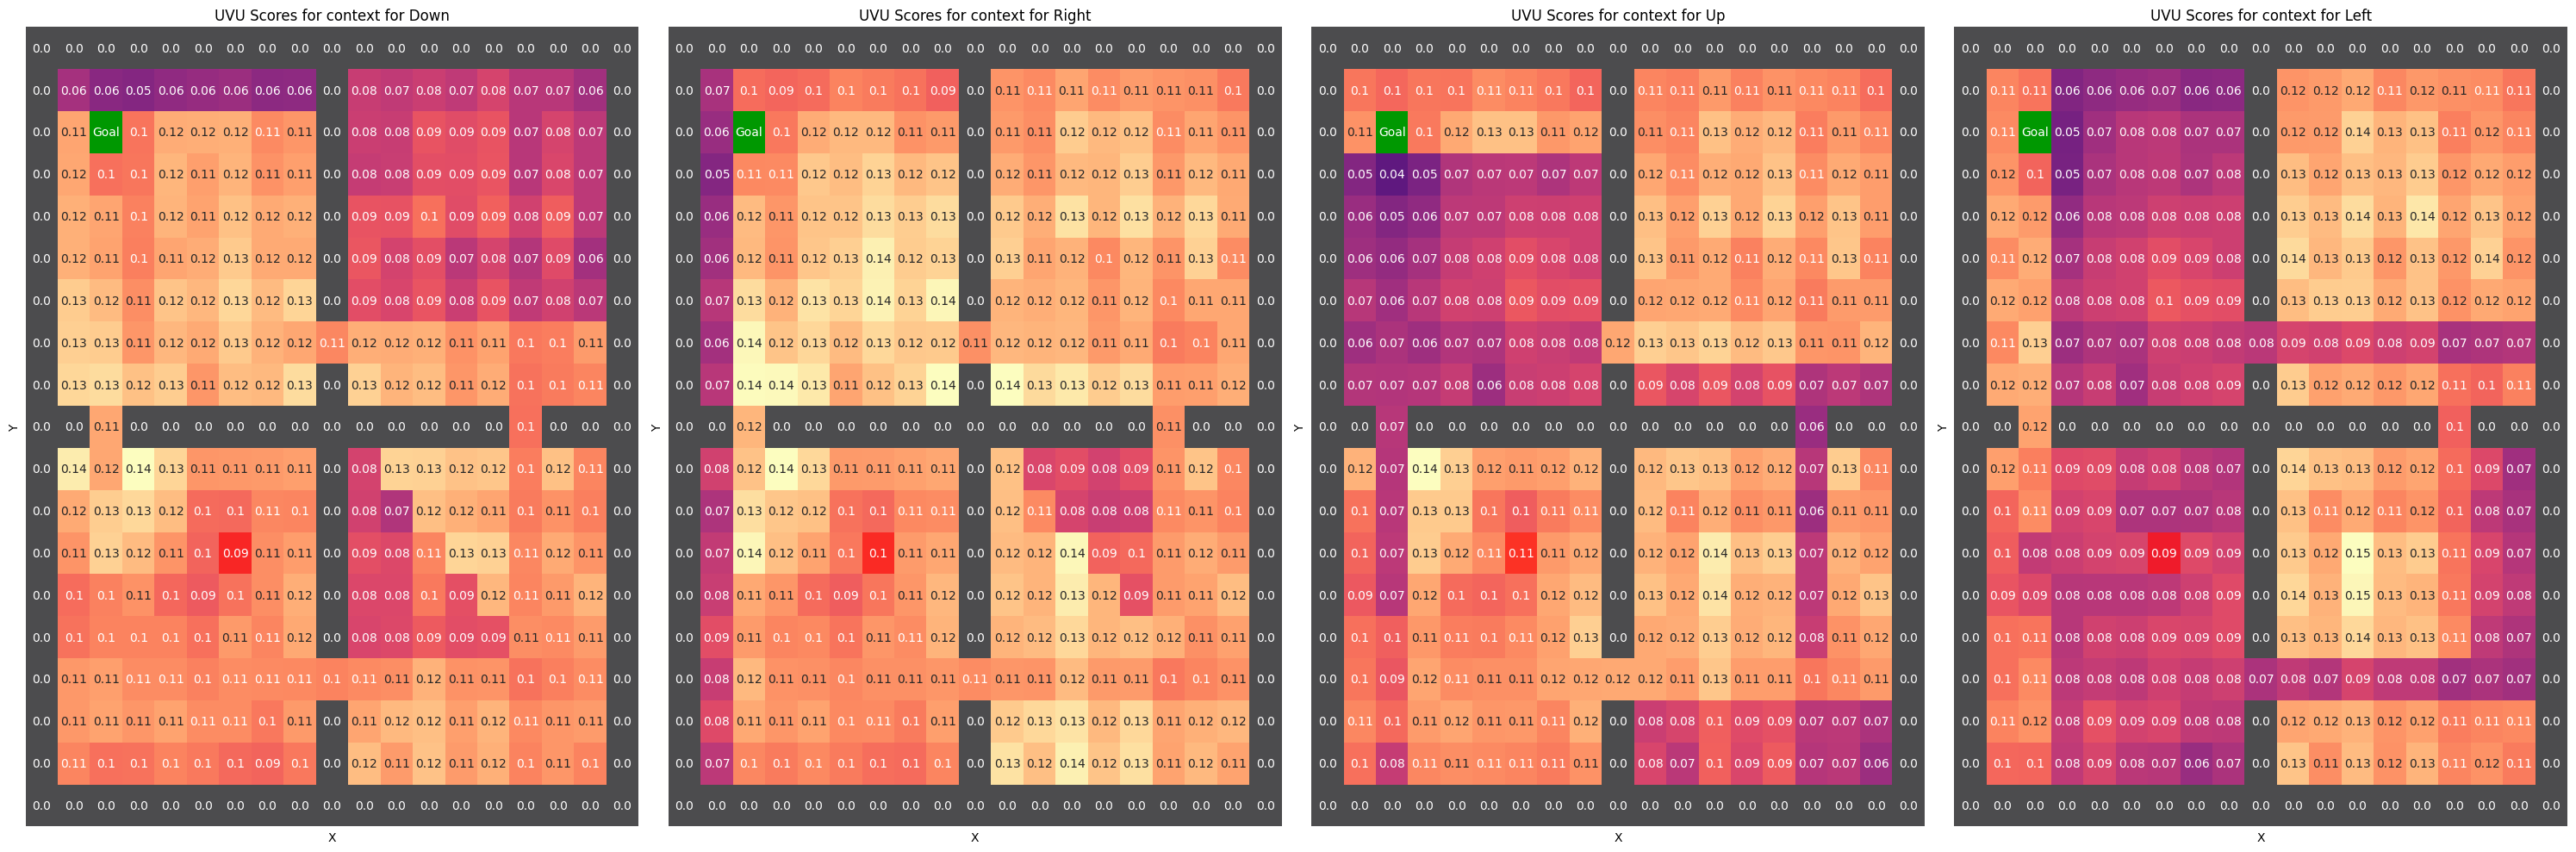

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0, use_cnn=use_cnn)
uvu_scores = uvu_scores
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout() 


In [23]:
use_cnn = True

env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )
    
val_env = gym_wrapper_state(gym.make(
        'MiniGrid-FourRooms-v1', 
        agent_pos= train_config['agent positions'],
        goal_pos = train_config['goal positions'],
        doors_pos = train_config['topologies'],
        agent_dir = train_config['agent directions'],
        size=size
    ),
)

obs, _ = env.reset()
obs2, _ = env.reset()

using DQNBaseAction


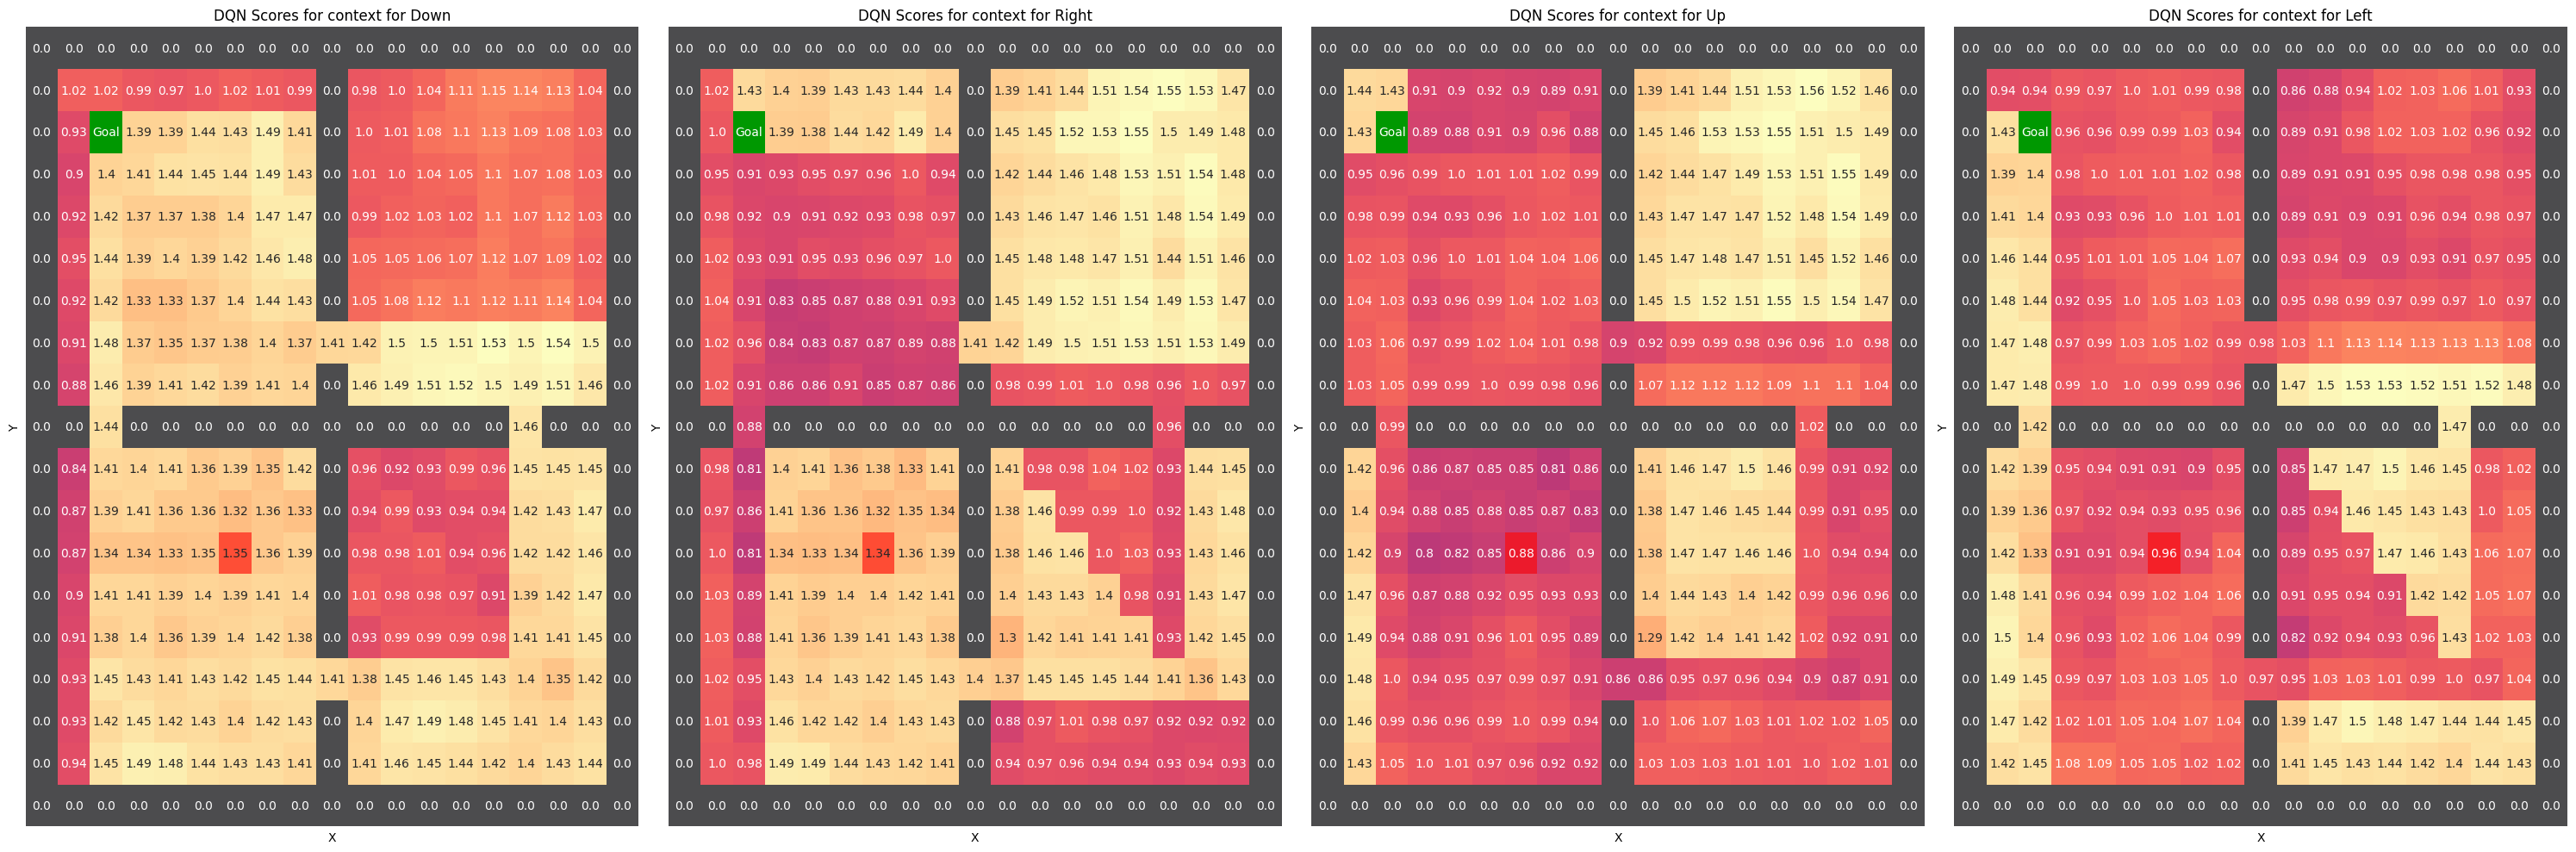

In [25]:
from plot_interactive import find_states, plot_env_heatmap

agent = DQN(
    env,
    val_env=val_env,
    tau=0.1,
    lr=1e-4,
    gamma=0.99,
    device='cuda',
    use_cnn=use_cnn,
    use_action=True, 
    use_dual=False, 
    use_norm=False, 
    modulation='mult',
    hidden_layers=[512, 512, 512],
    init_func='orthogonal',
    scale=1
)

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_dqn_scores(agent, context, 0, use_cnn=use_cnn)
uvu_scores = uvu_scores 
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False,
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout() 


In [28]:
env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )

done = False
context = 0
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
eps = 0.1
for step in tqdm(range(1, 5000)):
    state = get_state(obs, use_cnn=use_cnn)
    q = state_to_q_np[context, state[0], state[1], state[2]]
    if np.random.random() < eps:
        action = env.action_space.sample()
    else:
        action = q.argmax() if isinstance(q, np.ndarray) else np.array(q).argmax()
    
    obs_prime, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state_next = get_state(obs_prime, use_cnn=use_cnn)
    q_next = state_to_q_np[context, state_next[0], state_next[1], state_next[2]]
    next_action = q_next.argmax()
        
    agent.buffer.update(obs, action, reward, obs_prime, next_action, int(done), q_value=q)
    obj_moving_tuple = (context, *state[:3])
    agent.counter.add(obj_moving_tuple, step)
    obs = obs_prime
    if done:
        env.get_wrapper_attr('set_context')(context)
        obs, _ = env.reset()
    
    if agent.buffer.size > 128:
        agent.update_step(128)
        agent.soft_update()
    

100%|██████████| 4999/4999 [01:01<00:00, 81.00it/s]


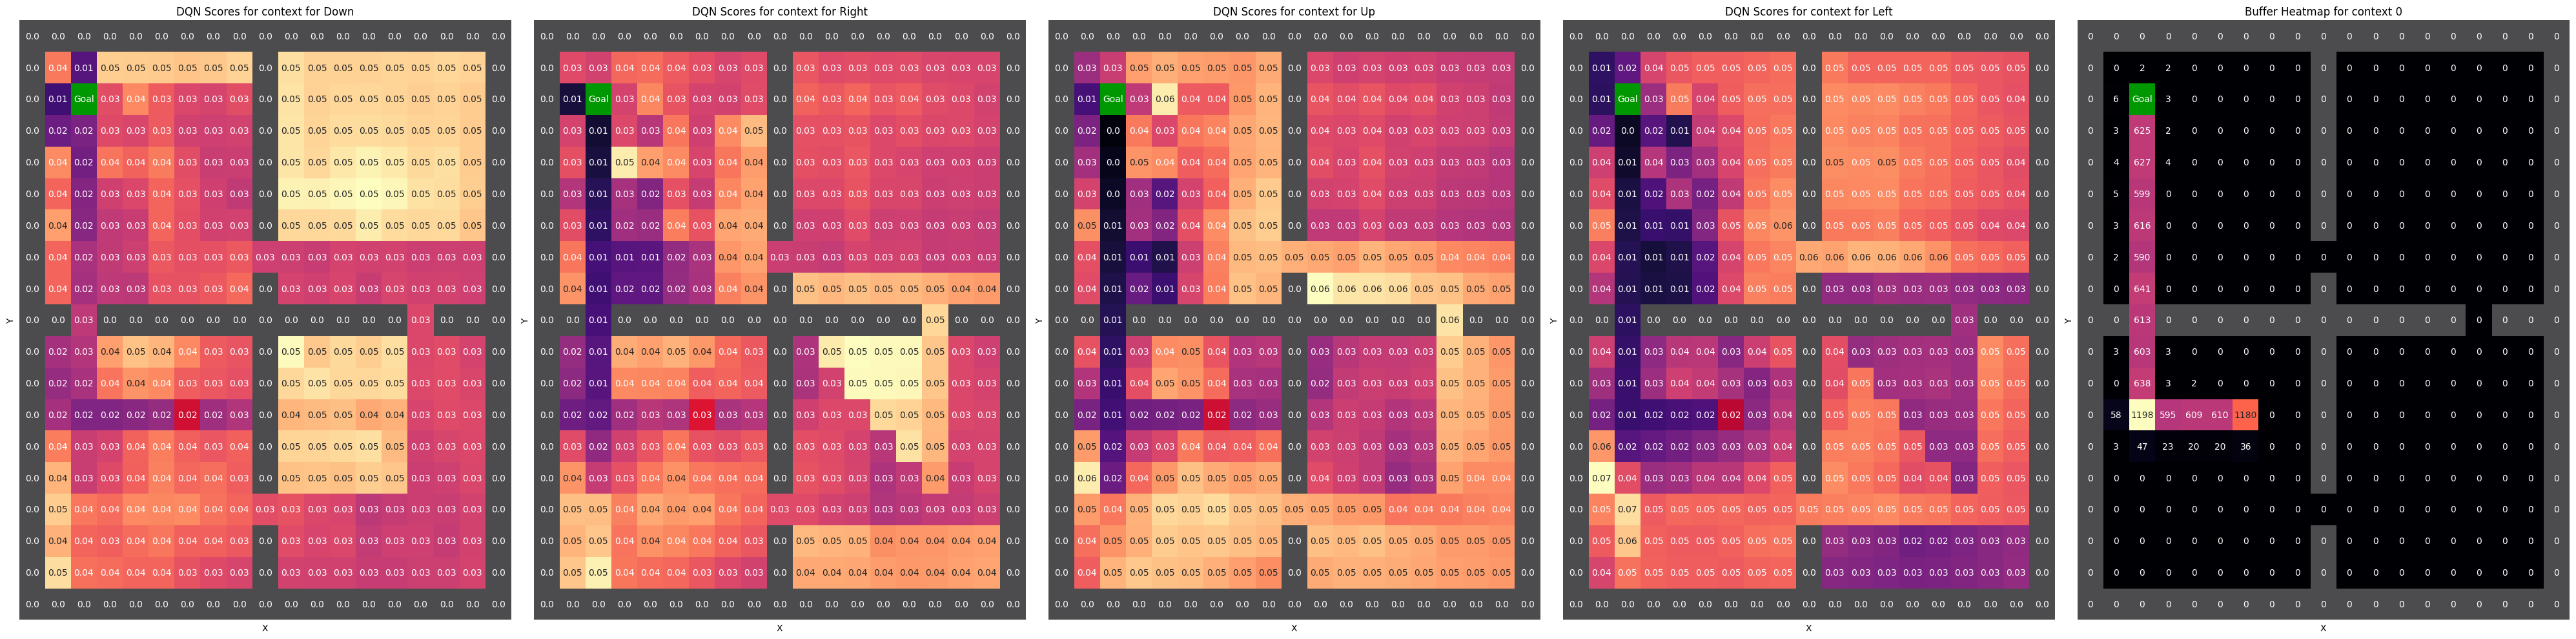

In [29]:
from plot_interactive import find_states, plot_env_heatmap, find_states

fig, axes = plt.subplots(1, 5, figsize=(40, 10))
context = 0
_, _, uvu_scores = record_dqn_scores(agent, context, 0, use_cnn=use_cnn)
uvu_scores = uvu_scores / 100
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

relevant_buffer = np.zeros((200, 19, 19))
relevant_buffer_states = find_states(
    agent.counter.all_states, 5000, agent.buffer.capacity
)
for state in relevant_buffer_states:
    relevant_buffer[*state] += 1

plot_env_heatmap(
    relevant_buffer[context],
    context_info,
    "Buffer Counts",
    f"Buffer Heatmap for context {context}",
    axes[4],
)

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)

plt.tight_layout() 


In [15]:
def uvu_loop(use_cnn, use_action, use_dual, use_norm, init, mod, axes, device='cuca'):
    env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )
    
    val_env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size
        ),
    )

    agent = UVU(
        env=env,
        val_env=val_env,
        tau=0.1,
        lr=1e-4,
        gamma=0.99,
        boostrap_prob=1.0,
        device=device,
        modulation=mod, 
        use_cnn=use_cnn,
        use_action=use_action, 
        use_dual=use_dual, 
        use_norm=use_norm, 
        hidden_layers=[512, 512, 512],
        hidden_layers_g=[512, 512],
        init_func=init,
        scale=1, 
        residual=True,
        zero_params=False, 
        num_heads=512
    )
    context = 0
    _, _, uvu_scores = record_uvu_scores(agent, context, 0, use_cnn=use_cnn, device=device)
    uvu_scores = uvu_scores 
    env.get_wrapper_attr('set_context')(context)
    obs, _ = env.reset()
    context_info = env.get_wrapper_attr('context_info')(context)
    context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
    agent_pos = env.get_wrapper_attr('agent_pos')

    plot_env_heatmap(
        uvu_scores[0].squeeze(),
        context_info,
        'UVU Scores',
        f'UVU Scores for context for Down (INIT)',
        axes[0, 0],
        agent_pos=agent_pos,
        intize=False
    )

    plot_env_heatmap(
        uvu_scores[1].squeeze(),
        context_info,
        'UVU Scores',
        f'UVU Scores for context for Right (INIT)',
        axes[0, 1],
        agent_pos=agent_pos,
        intize=False,
    )

    plot_env_heatmap(
        uvu_scores[2].squeeze(),
        context_info,
        'UVU Scores',
        f'UVU Scores for context for Up (INIT)',
        axes[0, 2],
        agent_pos=agent_pos,
        intize=False
    )

    plot_env_heatmap(
        uvu_scores[3].squeeze(),
        context_info,
        'UVU Scores',
        f'UVU Scores for context for Left (INIT)',
        axes[0, 3],
        agent_pos=agent_pos,
        intize=False
    )


    env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )

    done = False
    context = 0
    env.get_wrapper_attr('set_context')(context)
    obs, _ = env.reset()
    loss = 0
    postfix = {}
    for step in (pbar := tqdm(range(1, 5001))):
        state = get_state(obs, use_cnn=use_cnn)
        q = state_to_q_np[context, state[0], state[1], state[2]]
        if np.random.random() < 0.0:
            action = env.action_space.sample()
        else:
            action = q.argmax() if isinstance(q, np.ndarray) else np.array(q).argmax()
        
        obs_prime, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state_next = get_state(obs_prime, use_cnn=use_cnn)
        q_next = state_to_q_np[context, state_next[0], state_next[1], state_next[2]]
        next_action = q_next.argmax()
            
        agent.buffer.update(obs, action, reward, obs_prime, next_action, int(done), q_value=q)
        obs = obs_prime

        if done:
            env.get_wrapper_attr('set_context')(context)
            obs, _ = env.reset()
        
        if agent.buffer.size > 128:
            loss = agent.update_step(128)
            postfix["loss"] = loss.item()
            pbar.set_postfix(postfix)
            agent.soft_update()

    context = 0
    _, _, uvu_scores = record_uvu_scores(agent, context, 0, use_cnn=use_cnn, device=device)
    uvu_scores = uvu_scores
    env.get_wrapper_attr('set_context')(context)
    obs, _ = env.reset()
    context_info = env.get_wrapper_attr('context_info')(context)
    context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
    agent_pos = env.get_wrapper_attr('agent_pos')

    plot_env_heatmap(
        uvu_scores[0].squeeze(),
        context_info,
        'UVU Scores',
        f'UVU Scores for context for Down',
        axes[1, 0],
        agent_pos=agent_pos,
        intize=False
    )

    plot_env_heatmap(
        uvu_scores[1].squeeze(),
        context_info,
        'UVU Scores',
        f'UVU Scores for context for Right',
        axes[1, 1],
        agent_pos=agent_pos,
        intize=False
    )

    plot_env_heatmap(
        uvu_scores[2].squeeze(),
        context_info,
        'UVU Scores',
        f'UVU Scores for context for Up',
        axes[1, 2],
        agent_pos=agent_pos,
        intize=False
    )

    plot_env_heatmap(
        uvu_scores[3].squeeze(),
        context_info,
        'UVU Scores',
        f'UVU Scores for context for Left',
        axes[1, 3],
        agent_pos=agent_pos,
        intize=False
    )


    plt.tight_layout() 


def draw_uvu_heatmaps(hyperparams, device='cuda'):
    cnns = hyperparams[0]
    acts = hyperparams[1]
    duals = hyperparams[2]
    norms = hyperparams[3]
    inits = hyperparams[4]
    mods = hyperparams[5]

    for init in inits:
        for use_cnn in cnns:
            for use_act in acts:
                for use_dual in duals:
                    for use_norm in norms:
                        for mod in mods:
                        
                            fig, axes = plt.subplots(2, 4, figsize=(30, 20))
                            name_cnn = 'CNN' if use_cnn else "MLP"
                            name_dual = 'Dual' if use_dual else "Single"
                            name_norm = 'Norm' if use_norm else ""
                            print(f'Running {init} | {name_cnn} | {name_dual} | {name_norm} | {mod}')

                            fig.suptitle(f'UVU for {init} | {name_cnn} | {name_dual} | {name_norm} | {mod}', fontsize=24)
                            uvu_loop(use_cnn, use_act, use_dual, use_norm, init, mod, axes, device)
                            plt.show()


Running orthogonal | CNN | Single | Norm | one_hot
using DQNBaseAction
using DQNBaseAction


100%|██████████| 5000/5000 [02:16<00:00, 36.67it/s, loss=1.84]   


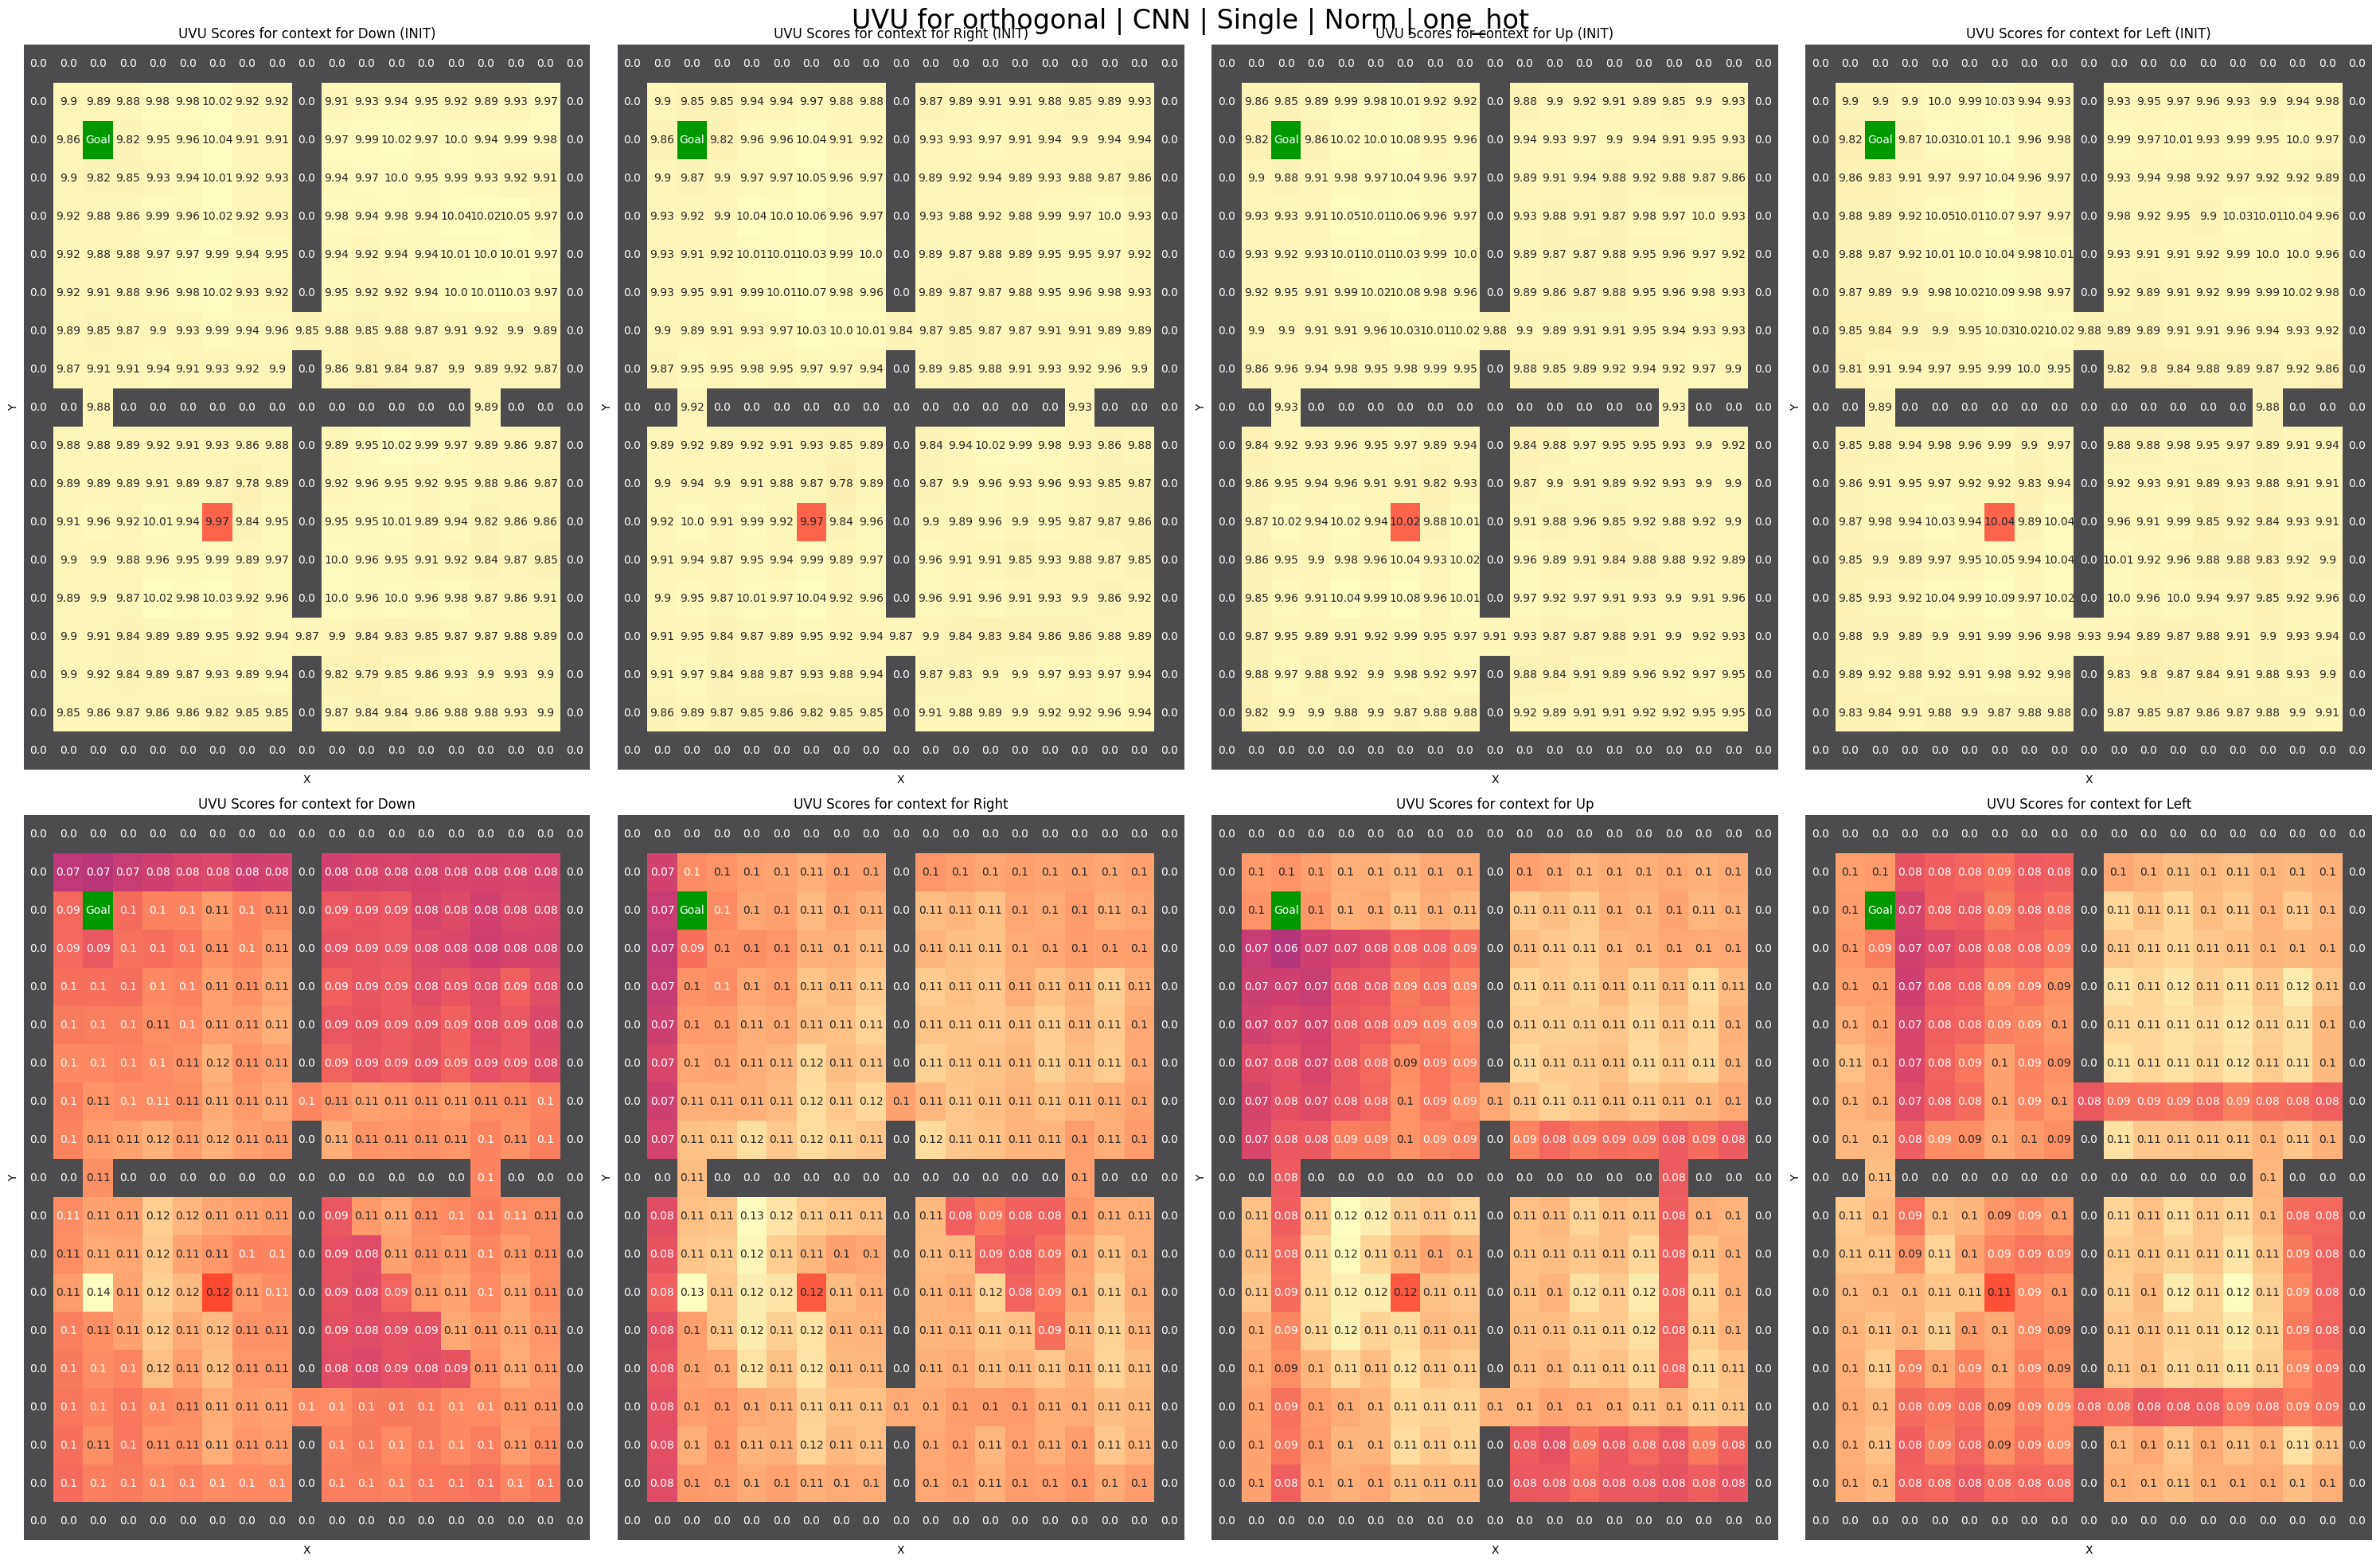

Running orthogonal | CNN | Single | Norm | add
using DQNBaseAction
using DQNBaseAction


100%|██████████| 5000/5000 [02:20<00:00, 35.59it/s, loss=4.67]   


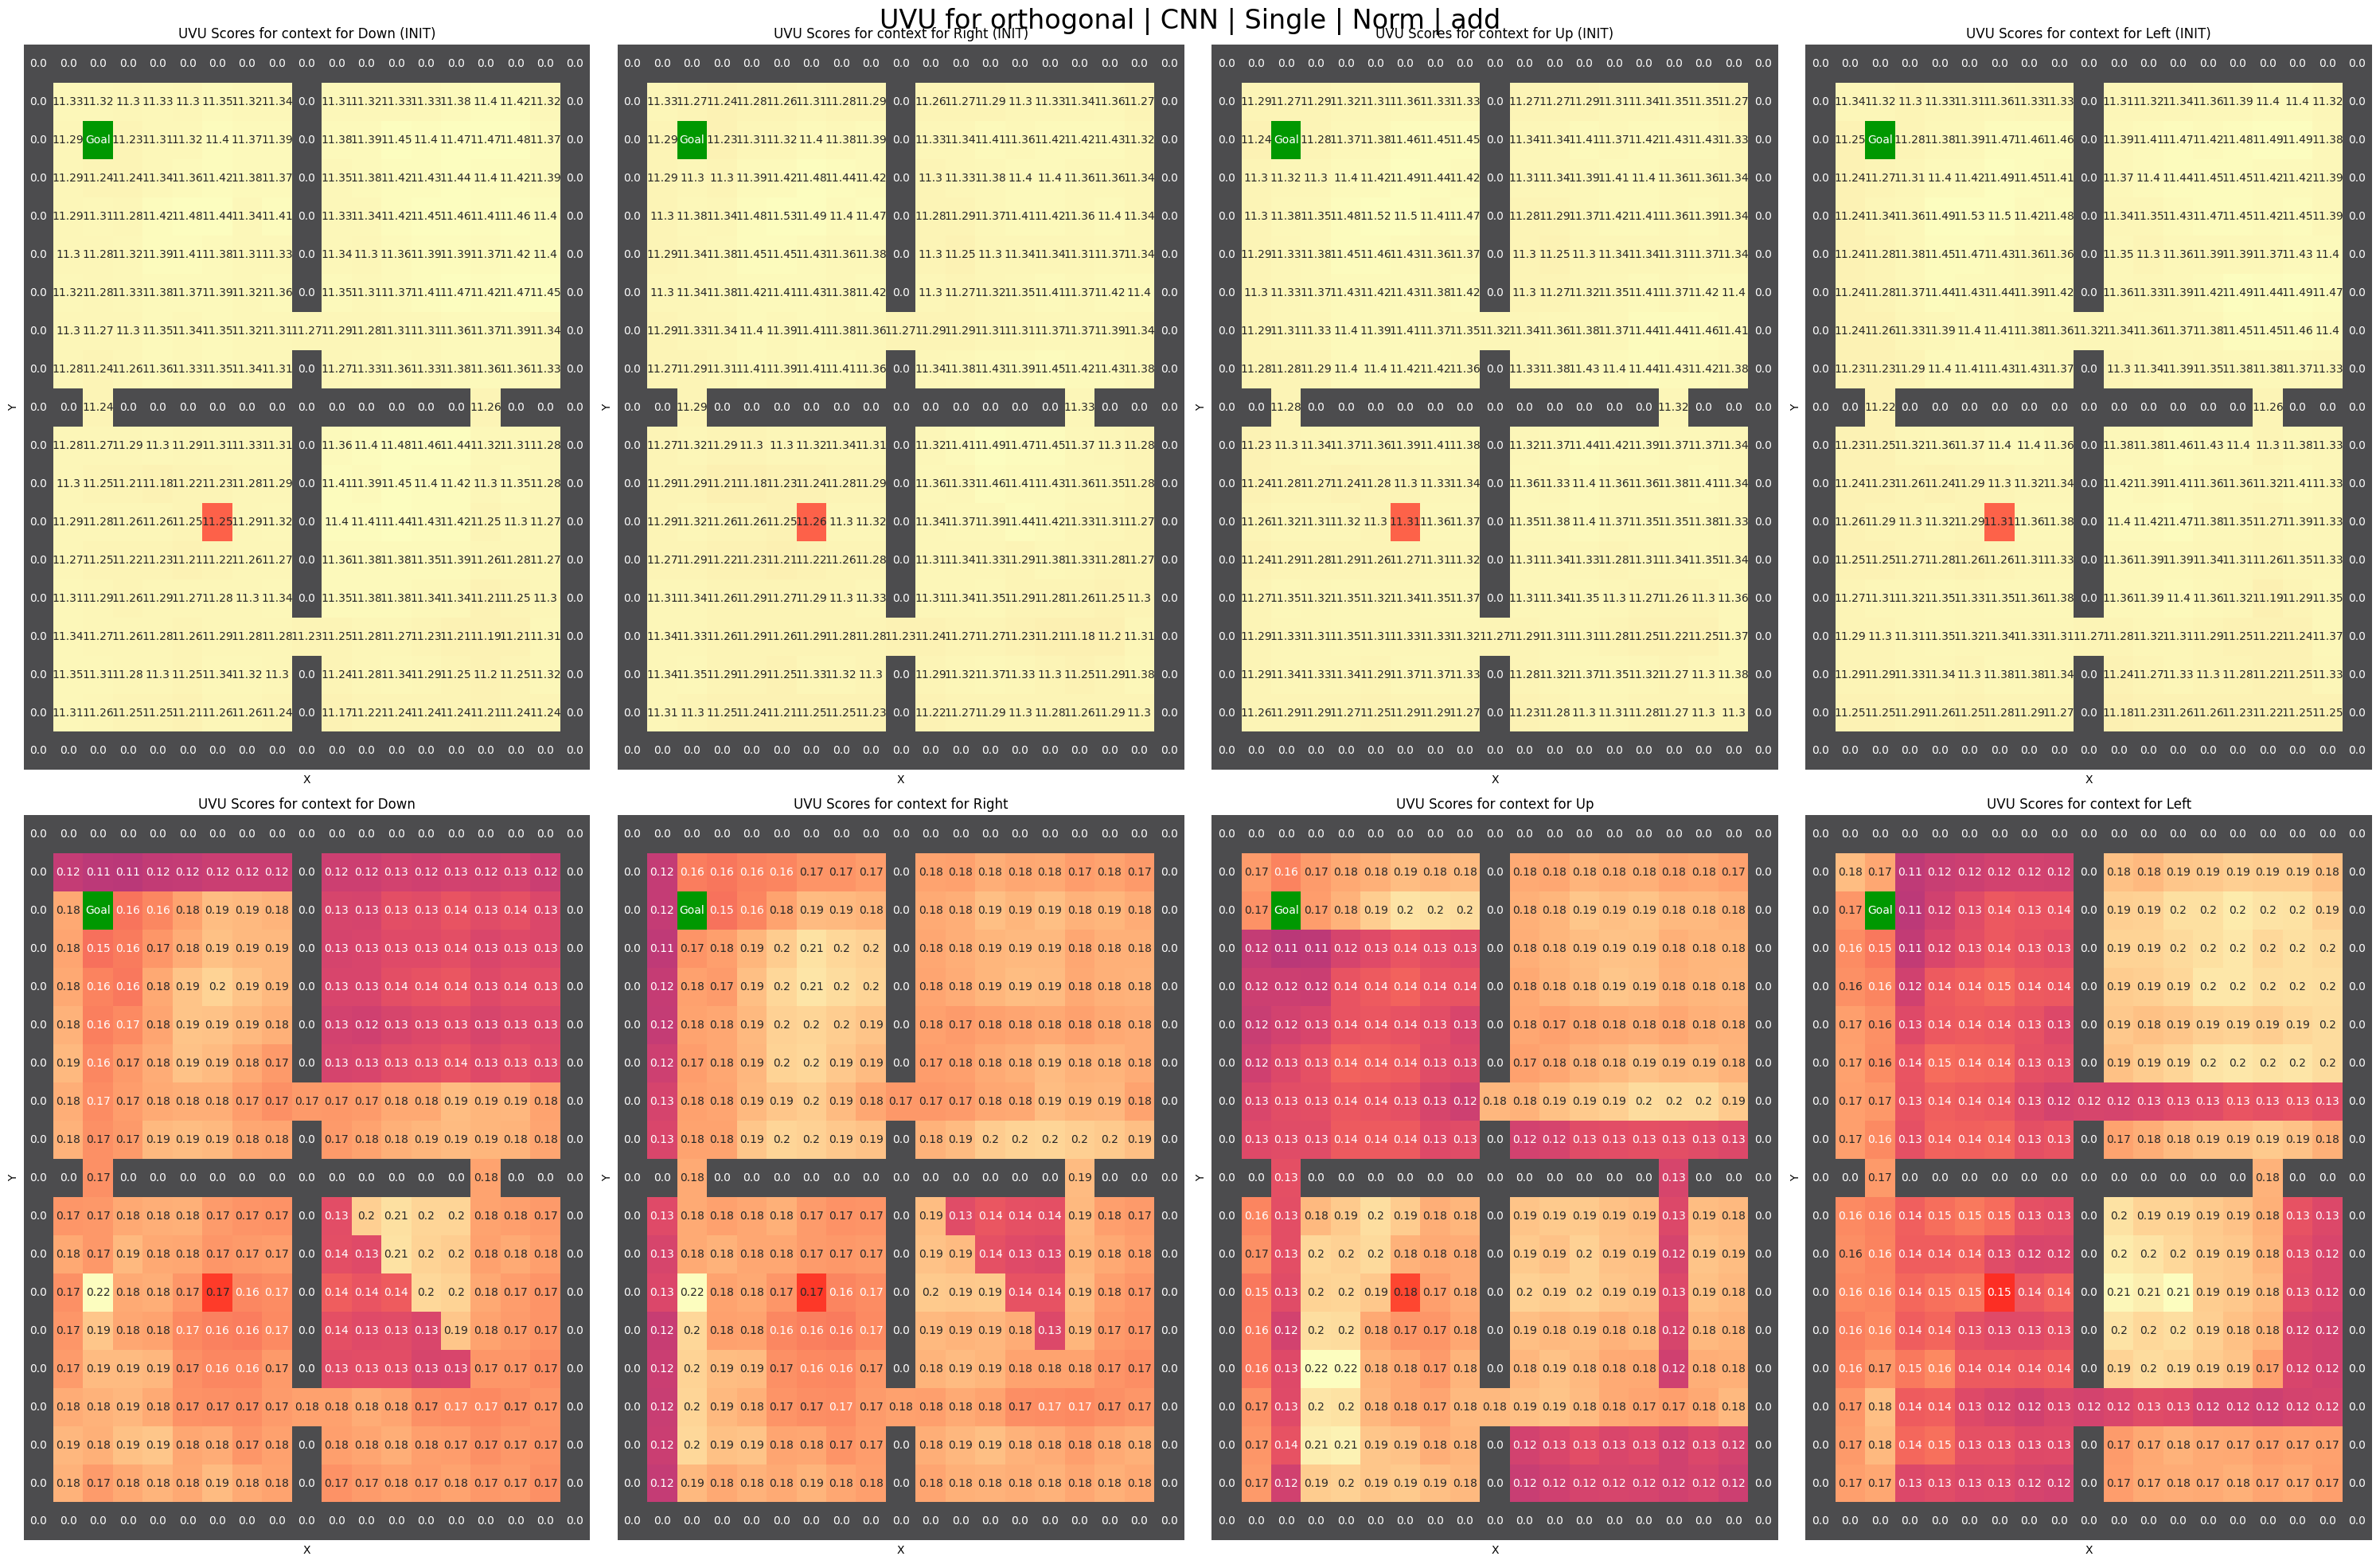

Running orthogonal | CNN | Single | Norm | concat
using DQNBaseAction
using DQNBaseAction


 85%|████████▌ | 4270/5000 [02:01<00:20, 35.24it/s, loss=1.14] 


KeyboardInterrupt: 

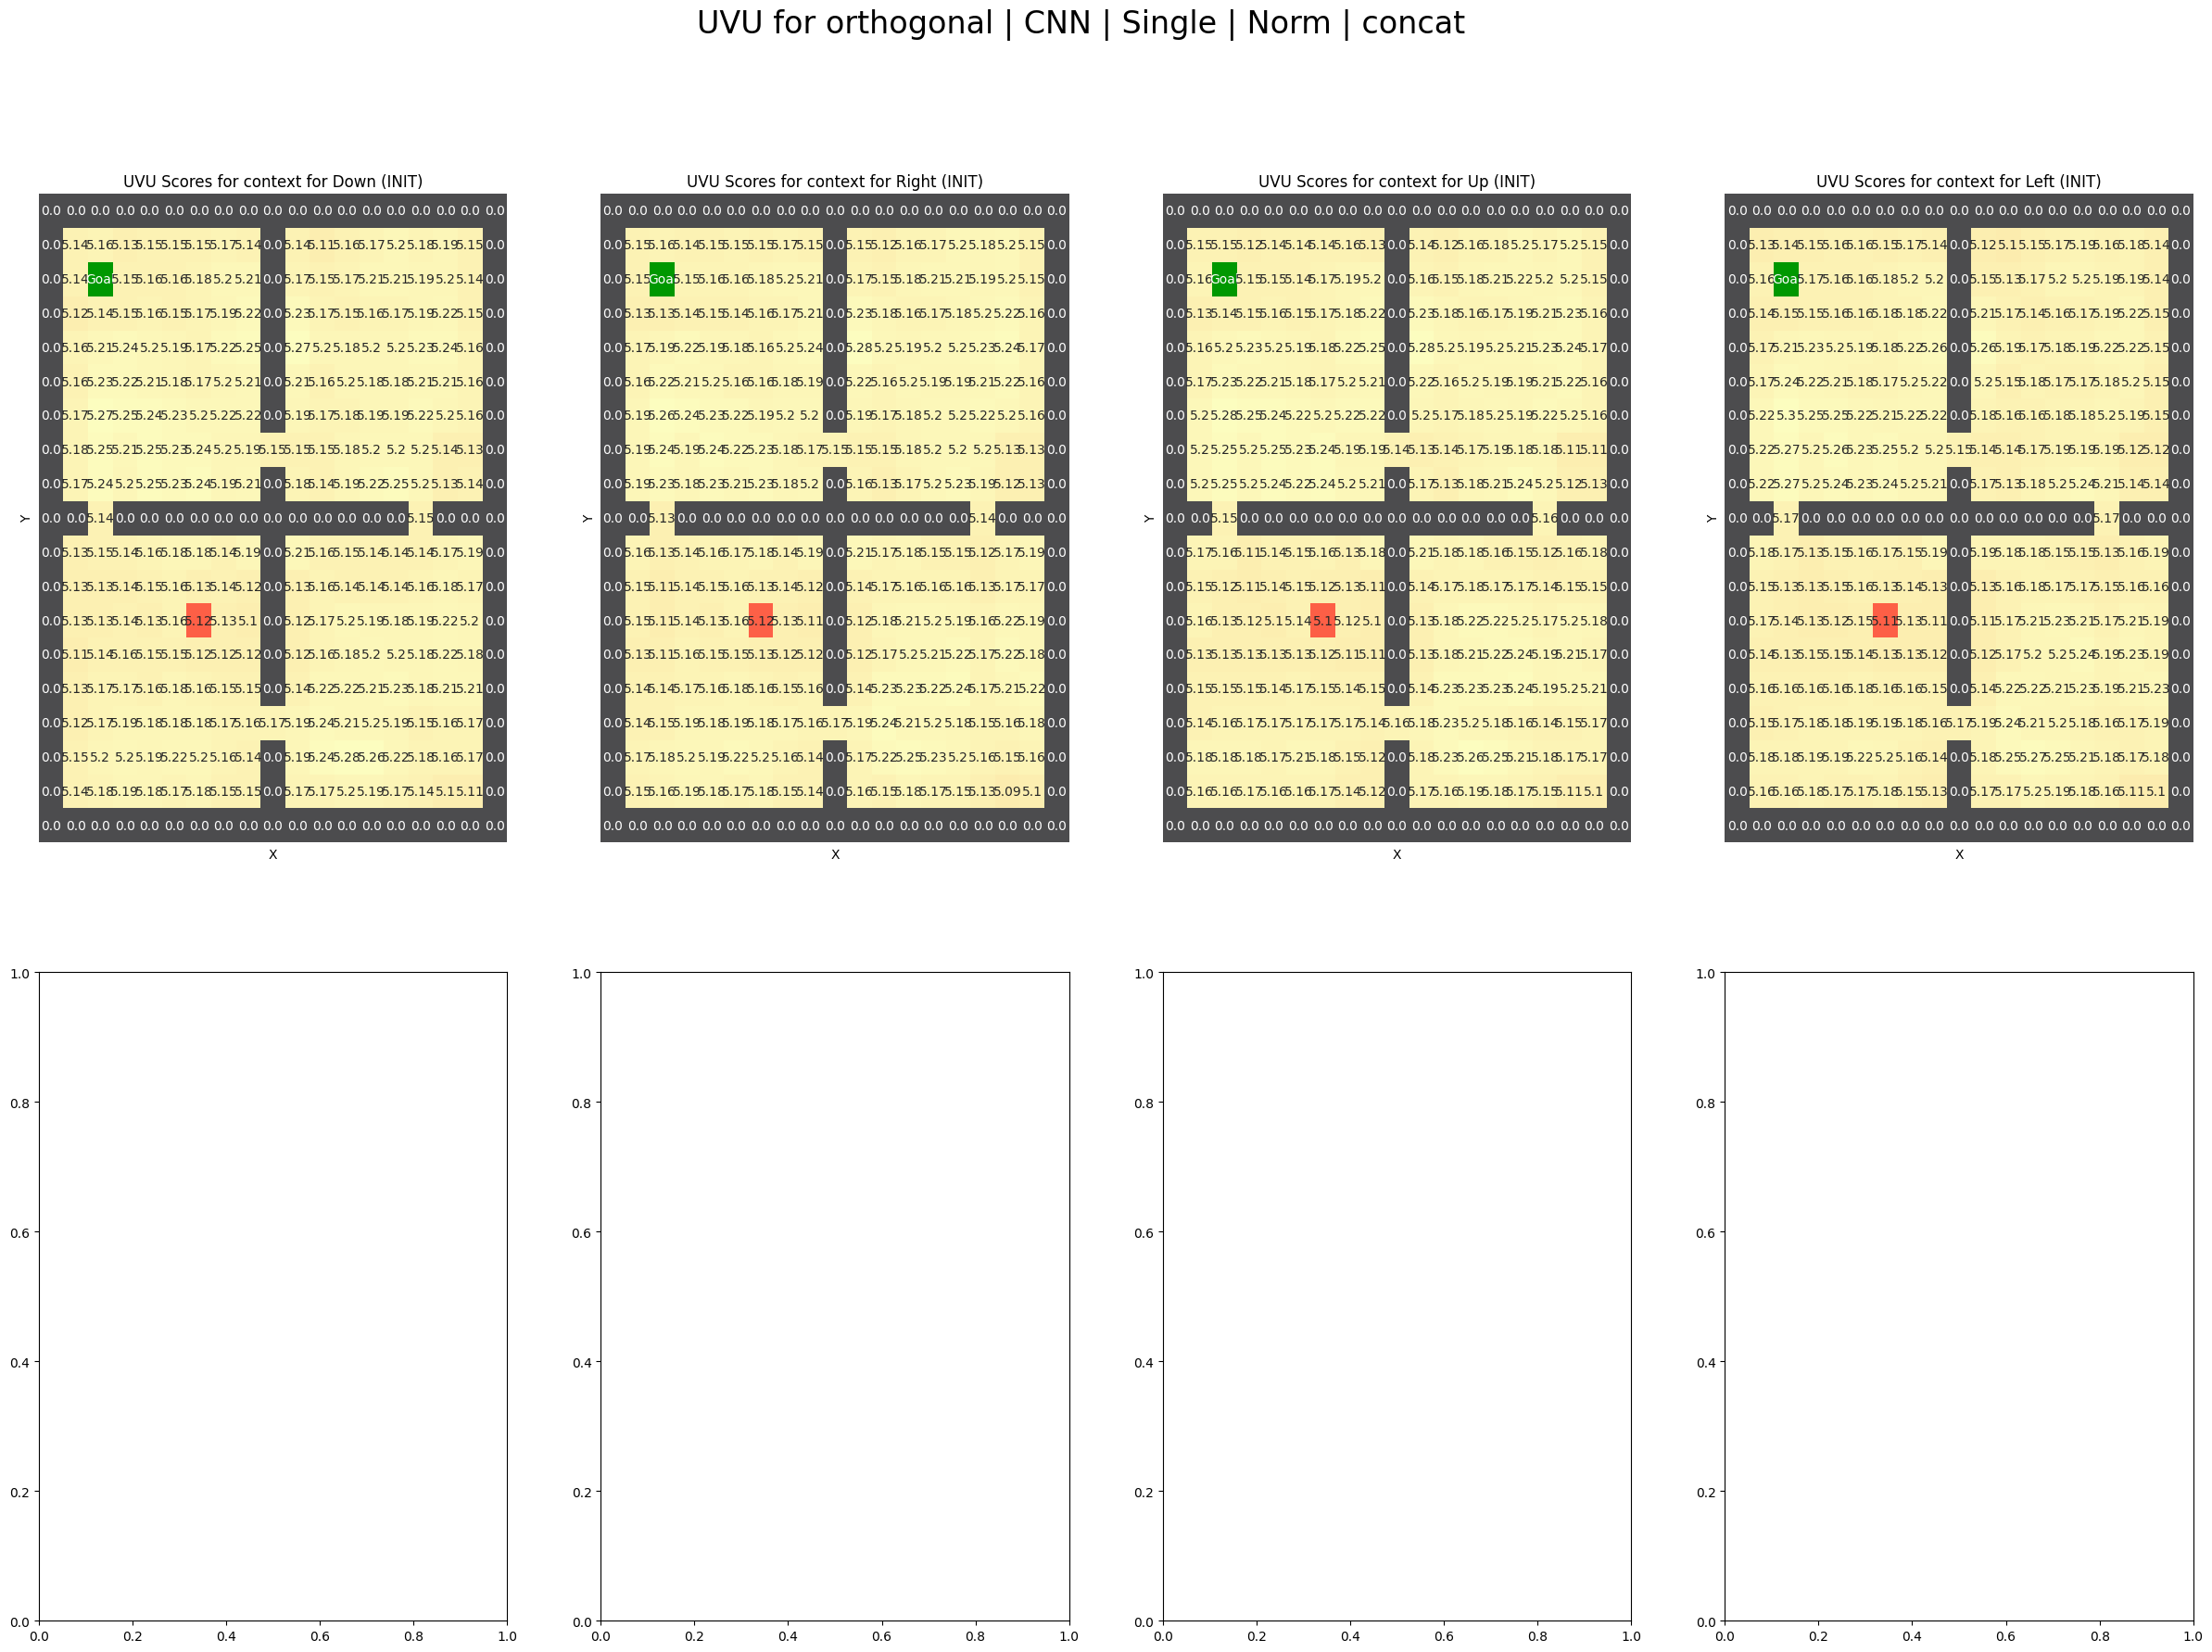

In [16]:
hyperparameters = [
    [True],                  
    [True],                         
    [False],                  
    [True, False],                  
    ["orthogonal", "kaiming"],
    ["one_hot", "add", "concat", "mult"],     
]  

draw_uvu_heatmaps(hyperparameters, device='cuda')

## Regression Tests

In [6]:
from dqn_experiments.regression_exp_utils import run_experiment
import dill 
import torch 
import random
import tabulate
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
with open('action_values/full_dataset_cnn.pl', 'rb') as file:
    cnn_dataset = dill.load(file)
    file.close()

100%|██████████| 500000/500000 [40:26<00:00, 206.08it/s, loss=2.67e-6, val_score=0.875]  


Loading best model with score: 1.0


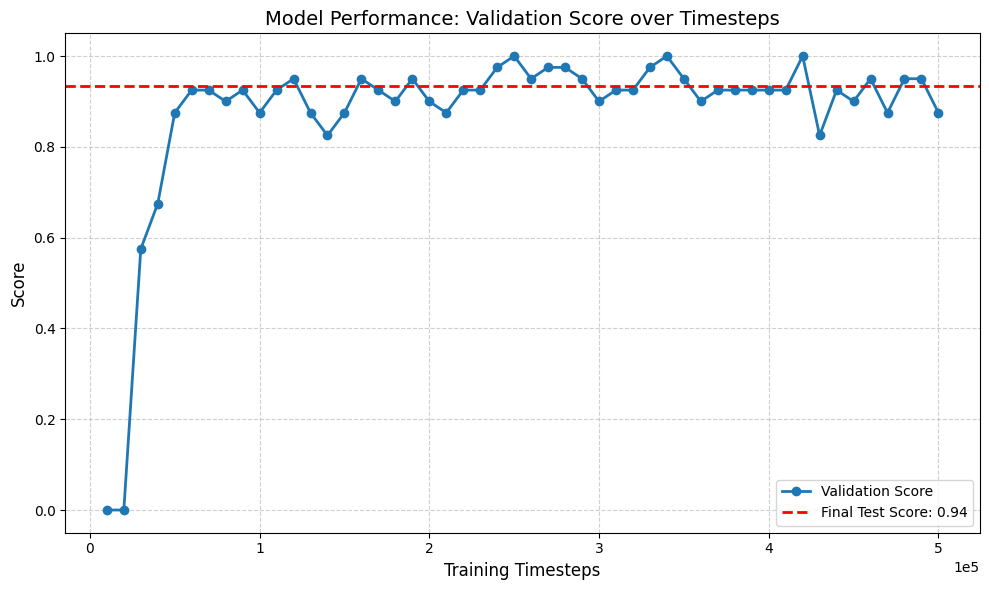

In [9]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

val_scores, test_scores = run_experiment(cnn_dataset, timesteps=int(5e5), batch_size=128, use_cnn=True, device='cuda', loss=torch.nn.HuberLoss)

total_timesteps = 500000
val_freq = 10000
timesteps = np.arange(val_freq, total_timesteps + val_freq, val_freq)

plt.figure(figsize=(10, 6))

plt.plot(timesteps, val_scores, 
         marker='o',         
         linestyle='-',       
         linewidth=2, 
         color='#1f77b4',     
         label='Validation Score')

plt.axhline(y=np.mean(test_scores), 
            color='r', 
            linestyle='--', 
            linewidth=2, 
            label=f'Final Test Score: {np.mean(test_scores):.2f}')

plt.title('Model Performance: Validation Score over Timesteps', fontsize=14)
plt.xlabel('Training Timesteps', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 500000/500000 [37:35<00:00, 221.70it/s, loss=2.57e-6, val_score=0.925]  


Loading best model with score: 0.975


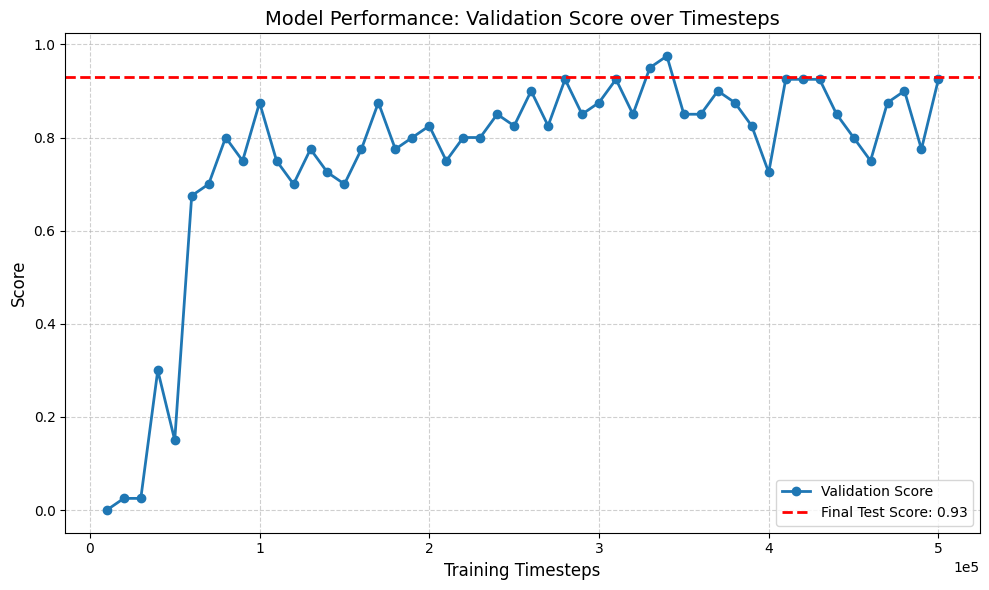

In [10]:
from dqn_experiments.regression_exp_utils import run_experiment
import dill 
import torch 
import random
import tabulate
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

with open('action_values/full_dataset_cnn.pl', 'rb') as file:
    cnn_dataset = dill.load(file)
    file.close()

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

val_scores, test_scores = run_experiment(cnn_dataset, timesteps=int(5e5), batch_size=32, use_cnn=True, device='cuda')

total_timesteps = 500000
val_freq = 10000
timesteps = np.arange(val_freq, total_timesteps + val_freq, val_freq)

plt.figure(figsize=(10, 6))

plt.plot(timesteps, val_scores, 
         marker='o',         
         linestyle='-',       
         linewidth=2, 
         color='#1f77b4',     
         label='Validation Score')

plt.axhline(y=np.mean(test_scores), 
            color='r', 
            linestyle='--', 
            linewidth=2, 
            label=f'Final Test Score: {np.mean(test_scores):.2f}')

plt.title('Model Performance: Validation Score over Timesteps', fontsize=14)
plt.xlabel('Training Timesteps', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 500000/500000 [37:14<00:00, 223.75it/s, loss=4.61e-6, val_score=1]      


Loading best model with score: 1.0


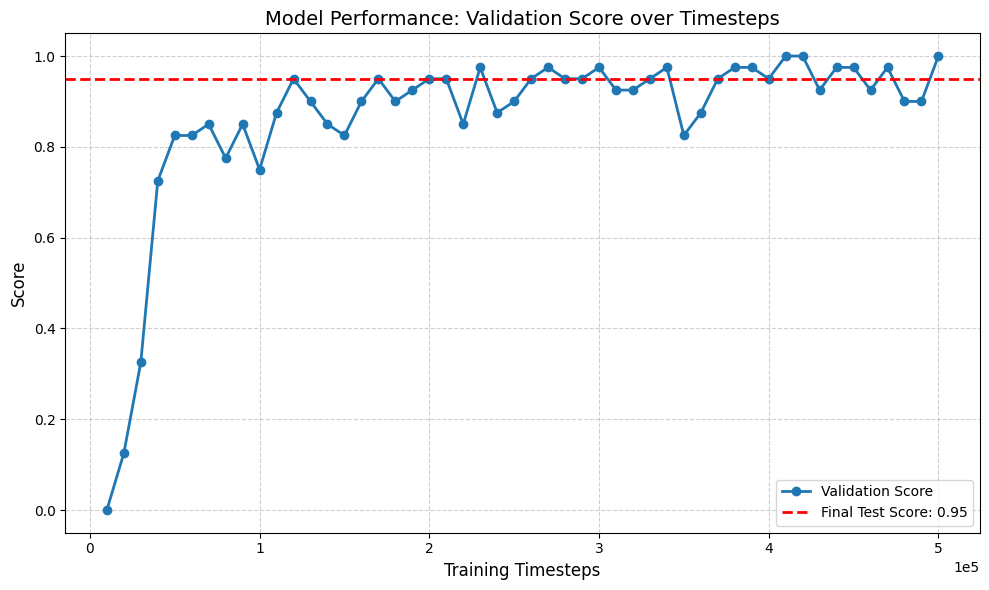

In [11]:
from dqn_experiments.regression_exp_utils import run_experiment
import dill 
import torch 
import random
import tabulate
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

with open('action_values/full_dataset_cnn.pl', 'rb') as file:
    cnn_dataset = dill.load(file)
    file.close()

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

val_scores, test_scores = run_experiment(cnn_dataset, timesteps=int(5e5), batch_size=64, use_cnn=True, device='cuda')

total_timesteps = 500000
val_freq = 10000
timesteps = np.arange(val_freq, total_timesteps + val_freq, val_freq)

plt.figure(figsize=(10, 6))

plt.plot(timesteps, val_scores, 
         marker='o',         
         linestyle='-',       
         linewidth=2, 
         color='#1f77b4',     
         label='Validation Score')

plt.axhline(y=np.mean(test_scores), 
            color='r', 
            linestyle='--', 
            linewidth=2, 
            label=f'Final Test Score: {np.mean(test_scores):.2f}')

plt.title('Model Performance: Validation Score over Timesteps', fontsize=14)
plt.xlabel('Training Timesteps', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()


100%|██████████| 500000/500000 [42:01<00:00, 198.33it/s, loss=2.06e-6, val_score=0.95]   


Loading best model with score: 0.975


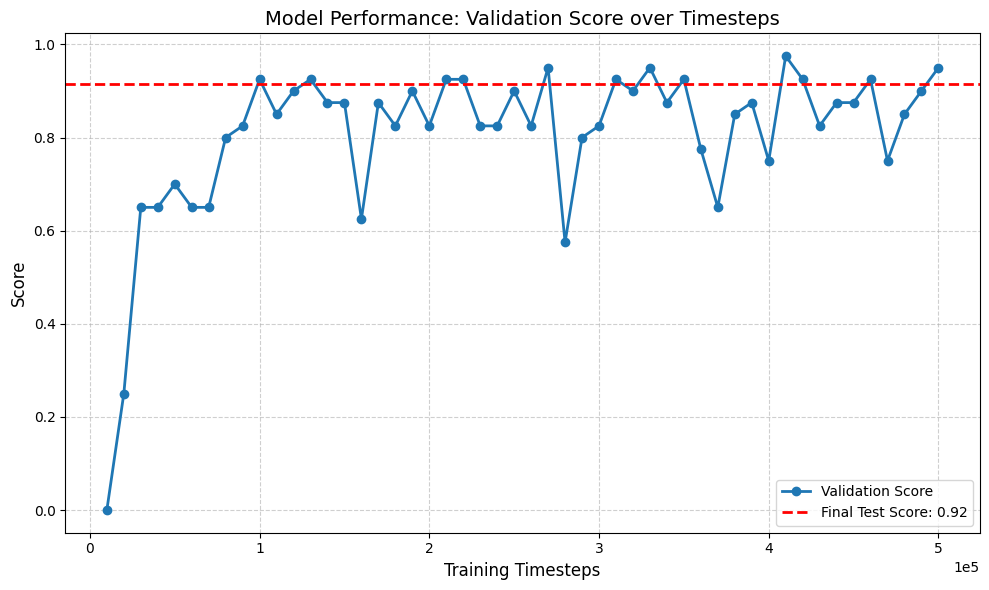

In [1]:
from dqn_experiments.regression_exp_utils import run_experiment
import dill 
import torch 
import random
import tabulate
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

with open('action_values/full_dataset_cnn.pl', 'rb') as file:
    cnn_dataset = dill.load(file)
    file.close()

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

val_scores, test_scores = run_experiment(cnn_dataset, timesteps=int(5e5), batch_size=128, use_cnn=True, device='cuda')

total_timesteps = 500000
val_freq = 10000
timesteps = np.arange(val_freq, total_timesteps + val_freq, val_freq)

plt.figure(figsize=(10, 6))

plt.plot(timesteps, val_scores, 
         marker='o',         
         linestyle='-',       
         linewidth=2, 
         color='#1f77b4',     
         label='Validation Score')

plt.axhline(y=np.mean(test_scores), 
            color='r', 
            linestyle='--', 
            linewidth=2, 
            label=f'Final Test Score: {np.mean(test_scores):.2f}')

plt.title('Model Performance: Validation Score over Timesteps', fontsize=14)
plt.xlabel('Training Timesteps', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 500000/500000 [52:51<00:00, 157.67it/s, loss=1.43e-6, val_score=0.975]  


Loading best model with score: 0.975


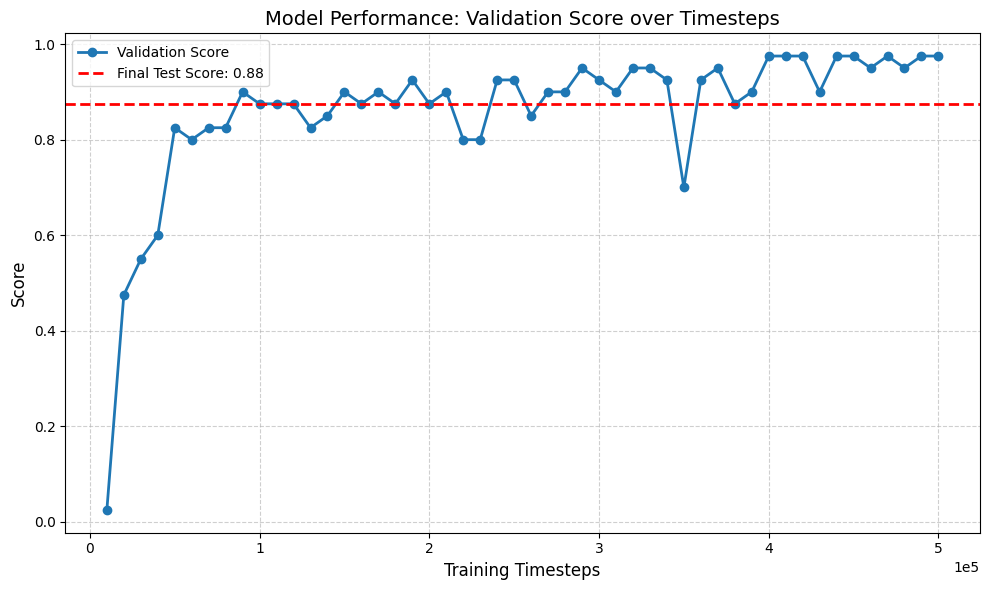

In [2]:
from dqn_experiments.regression_exp_utils import run_experiment
import dill 
import torch 
import random
import tabulate
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

with open('action_values/full_dataset_cnn.pl', 'rb') as file:
    cnn_dataset = dill.load(file)
    file.close()

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

val_scores, test_scores = run_experiment(cnn_dataset, timesteps=int(5e5), batch_size=256, use_cnn=True, device='cuda')

total_timesteps = 500000
val_freq = 10000
timesteps = np.arange(val_freq, total_timesteps + val_freq, val_freq)

plt.figure(figsize=(10, 6))

plt.plot(timesteps, val_scores, 
         marker='o',         
         linestyle='-',       
         linewidth=2, 
         color='#1f77b4',     
         label='Validation Score')

plt.axhline(y=np.mean(test_scores), 
            color='r', 
            linestyle='--', 
            linewidth=2, 
            label=f'Final Test Score: {np.mean(test_scores):.2f}')

plt.title('Model Performance: Validation Score over Timesteps', fontsize=14)
plt.xlabel('Training Timesteps', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
